In [12]:
# Research Question
# Is urban tree canopy coverage associated with median household income across Washington, DC wards?

import pandas as pd
import matplotlib.pyplot as plt

income = pd.read_csv("ACS_5-Year_Economic_Characteristics_DC_Ward.csv")
utc = pd.read_csv("Urban_Tree_Canopy_by_Ward_in_2020.csv")

In [13]:
# Clean income data

income_clean = income[['NAMELSAD', 'DP03_0062E']].copy()
income_clean = income_clean.rename(columns={
    'NAMELSAD': 'ward',
    'DP03_0062E': 'median_income'
})
income_clean['ward'] = income_clean['ward'].str.extract('(\d+)').astype(int)

In [14]:
# Clean tree canopy data

utc_clean = utc[['WARD', 'TCAN_PCT']].copy()

utc_clean = utc_clean.rename(columns={
    'WARD': 'ward',
    'TCAN_PCT' : 'tree_canopy_percentage',
})


In [16]:
df = income_clean.merge(utc_clean, on='ward')
df.head(8)

,ward,median_income,tree_canopy_percentage
0,2,131405,20.05
1,4,128210,49.43
2,7,69109,37.08
3,1,126387,23.76
4,8,50931,21.70
5,6,138047,17.38
6,3,141849,56.46
7,5,97814,29.01


In [17]:
df.describe()


,ward,median_income,tree_canopy_percentage
count,8.00000,8.000000,8.000000
mean,4.50000,110469.000000,31.858750
std,2.44949,34157.752632,14.477657
min,1.00000,50931.000000,17.380000
25%,2.75000,90637.750000,21.287500
50%,4.50000,127298.500000,26.385000
75%,6.25000,133065.500000,40.167500
max,8.00000,141849.000000,56.460000


In [18]:
df.corr(numeric_only=True)

,ward,median_income,tree_canopy_percentage
ward,1.000000,-0.752517,-0.134809
median_income,-0.752517,1.000000,0.211809
tree_canopy_percentage,-0.134809,0.211809,1.000000


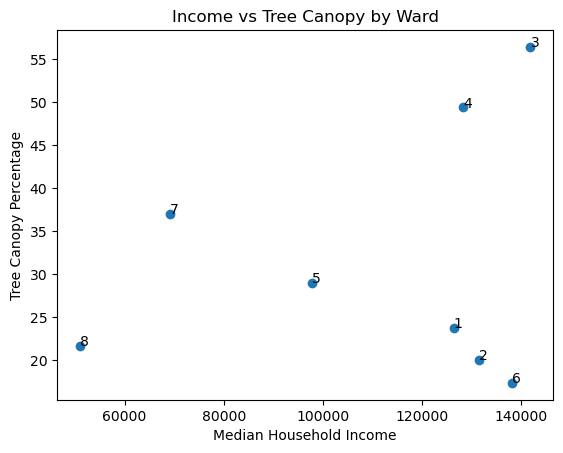

In [23]:
plt.scatter(df['median_income'], df['tree_canopy_percentage'])

for i in range(len(df)):
    plt.text(df['median_income'][i], df['tree_canopy_percentage'][i], str(df['ward'][i]))

plt.xlabel('Median Household Income')
plt.ylabel('Tree Canopy Percentage')
plt.title('Income vs Tree Canopy by Ward')

plt.show()